In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

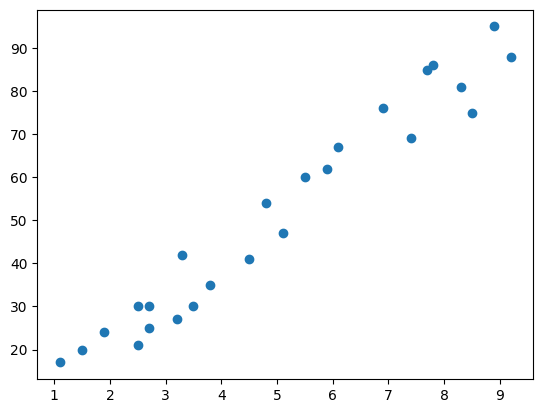

In [ ]:
dataset =pd.read_csv('studentscores.csv.csv')
plt.scatter(dataset['Hours'],dataset['Scores'])
plt.show()

In [ ]:
X=dataset.iloc[:,:1].values
y=dataset.iloc[:,1].values

In [ ]:
print(y)

[21 47 27 75 30 20 88 60 81 25 85 62 41 42 17 95 30 24 67 69 30 54 35 76
 86]


In [ ]:
class Model():
  def __init__(self,learning_rate,iterations):
    self.learning_rate=learning_rate
    self.iterations=iterations
  def predict(self,X):
    return X.dot(self.slope)+self.const
  def fit(self,X,y):
    self.m,self.n=X.shape
    self.X=X
    self.y=y
    self.slope=np.zeros(self.n)
    self.const=0
    for i in range(self.iterations):
      self.update_weights()
    return self
  def update_weights(self):
    y_pred=self.predict(self.X)
    dW= -(2*(self.X.T).dot(self.y-y_pred))/self.m
    db= -(2*np.sum(self.y-y_pred))/self.m
    self.slope=self.slope-self.learning_rate*dW
    self.const=self.const-self.learning_rate*db
    return self

In [ ]:
model =Model(learning_rate=0.01,iterations=1000)
model.fit(X,y)

[26.91171724 52.33687281 33.75695143 85.58515317 36.69062323 17.13281125
 92.43038736 56.24843521 83.62937197 28.86749844 77.76202838 60.1599976
 46.46952922 34.73484203 13.22124886 89.49671557 26.91171724 21.04437365
 62.1157788  74.82835658 28.86749844 49.40320102 39.62429503 69.93890359
 78.73991898]


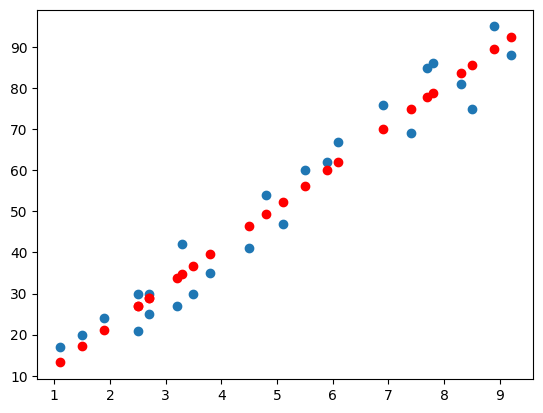

In [ ]:
y_pred=model.predict(X)
print(y_pred)
plt.scatter(dataset['Hours'],dataset['Scores'])
plt.scatter(X,y_pred,color='red')
plt.show()

In [ ]:
print(model.slope,model.const)

[9.77890599] 2.4644522714760995


In [ ]:
import matplotlib.axes as ax
from matplotlib.animation import FuncAnimation

class LinearRegression:
  def __init__(self):
    self.parameters = {}
    self.parameters['m'] = 0.0 # Initialize slope
    self.parameters['c'] = 0.0 # Initialize intercept

  def forward_propogation(self,train_input):
    m=self.parameters['m']
    c=self.parameters['c']
    predictions=np.multiply(m,train_input)+c
    return predictions

  def cost_function(self,prediction,train_output):
    # Using Mean Squared Error (MSE)
    cost=np.mean((train_output-prediction)**2)
    return cost

  def back_propogation(self,prediction,train_input,train_output):
    derivates={}
    df=(prediction-train_output)
    derivates['m']=-2*np.mean(np.multiply(df,train_input))
    derivates['c']=-2*np.mean(df)
    return derivates

  def update_parameters(self,derivates,learning_rate):
    self.parameters['m']=self.parameters['m']-learning_rate*derivates['m']
    self.parameters['c']=self.parameters['c']-learning_rate*derivates['c']

  def fit(self, X_train, y_train, learning_rate, iterations):
    """
    Trains the Linear Regression model using Gradient Descent.

    Args:
        X_train (np.ndarray): Training input features.
        y_train (np.ndarray): Training output (target) values.
        learning_rate (float): The learning rate for gradient descent.
        iterations (int): The number of iterations to train the model.
    """
    for i in range(iterations):
        # 1. Forward Propagation: Calculate predictions
        predictions = self.forward_propogation(X_train)

        # 2. Calculate Cost
        cost = self.cost_function(predictions, y_train)

        # 3. Back Propagation: Calculate gradients
        derivates = self.back_propogation(predictions, X_train, y_train)

        # 4. Update Parameters
        self.update_parameters(derivates, learning_rate)

        # Print progress periodically
        if (i + 1) % 100 == 0:
            print(f"Iteration {i+1}/{iterations}, Loss: {cost:.4f}")

    return self

In [ ]:
model =LinearRegression()
model.fit(X,y,learning_rate=0.01,iterations=1000)

Iteration 100/1000, Loss: 8424737424615425163788524164456563130457128960.0000
Iteration 200/1000, Loss: 88613928405993499745927890803463065826906970958526149183286251796099310643162816882671616.0000
Iteration 300/1000, Loss: 932068017289096075649796986623099048436684676616366691565114598817132385075962000968305275024566901539047491267645544985320382005248.0000
Iteration 400/1000, Loss: 9803772437138338106907119707358482107263192289326680891286138618338792994928358228749220349580500114019990473177306543298261706190863132883974338328085074150330246105724354560.0000
Iteration 500/1000, Loss: 103119034465680968919671759370365051293524743930926701875064374026802341314403768478780505867949002945143768794521811402228638342894251034599774273712692310381596740532316594034151521964982567641279121535476734617452544.0000
Iteration 600/1000, Loss: 108463709631332168708040211448101964574383457653807389548990627937981160506738280084126901301481190854647643300682727697395293220181680736487665810740760

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2901/2929533178.py:18: RuntimeWarning: overflow encountered in square
  cost=np.mean((train_output-prediction)**2)


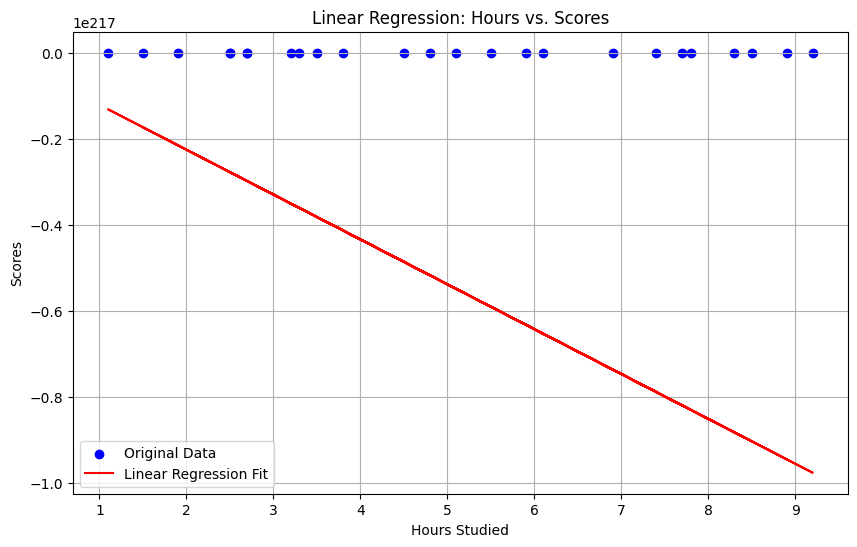

In [ ]:
y_pred_linear_regression = model.forward_propogation(X)

plt.figure(figsize=(10, 6))
plt.scatter(dataset['Hours'], dataset['Scores'], color='blue', label='Original Data')
plt.plot(X, y_pred_linear_regression, color='red', label='Linear Regression Fit')
plt.title('Linear Regression: Hours vs. Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Scores')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
dataset=pd.read_csv('50_Startups.csv', sep='\t')
X=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

In [ ]:
print(y)

[192261.83 191792.06 191050.39 182901.99 166187.94 156991.12 156122.51
 155752.6  152211.77 149759.96 146121.95 144259.4  141585.52 134307.35
 132602.65 129917.04 126992.93 125370.37 124266.9  122776.86 118474.03
 111313.02 110352.25 108733.99 108552.04 107404.34 105733.54 105008.31
 103282.38 101004.64  99937.59  97483.56  97427.84  96778.92  96712.8
  96479.51  90708.19  89949.14  81229.06  81005.76  78239.91  77798.83
  71498.49  69758.98  65200.33  64926.08  49490.75  42559.73  35673.41
  14681.4 ]


In [ ]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [ ]:
regressor.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=regressor.predict(X_test)
print(y_pred)

[103901.8969696  132763.05993126 133567.90370044  72911.78976736
 179627.92567224 115166.64864795  67113.5769057   98154.80686776
 114756.11555221 169064.01408795]


In [ ]:
for i, (pred,actual) in enumerate(zip(y_pred,y_test)):
  print(f"Sample {i+1}:Prediction = {pred}, Actual= {actual}")

Sample 1:Prediction = 103901.89696960004, Actual= 103282.38
Sample 2:Prediction = 132763.05993125628, Actual= 144259.4
Sample 3:Prediction = 133567.90370043818, Actual= 146121.95
Sample 4:Prediction = 72911.78976735754, Actual= 77798.83
Sample 5:Prediction = 179627.92567223712, Actual= 191050.39
Sample 6:Prediction = 115166.64864795282, Actual= 105008.31
Sample 7:Prediction = 67113.57690570195, Actual= 81229.06
Sample 8:Prediction = 98154.80686776247, Actual= 97483.56
Sample 9:Prediction = 114756.11555221121, Actual= 110352.25
Sample 10:Prediction = 169064.0140879458, Actual= 166187.94


In [ ]:
print("Coefficients:",regressor.coef_)
print("Intercept:",regressor.intercept_)

Coefficients: [0.77884104 0.0293919  0.03471025]
Intercept: 42989.00816508669


x1 = 0.77884104
x2 = 0.0293919  
x3 = 0.03471025